## Import data

In [1]:
import polars as pl

pdb_boltz = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.boltz_rmsd.parquet")
pdb_boltz_conf = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.conf_boltz.parquet")

pdb_boltz = pdb_boltz.join(
    pdb_boltz_conf.select(pl.col("job_name"), pl.col("iptm"), pl.col("ptm")),
    on="job_name",
)

# neff = pl.read_parquet("../../data/pdb/triad/neff/all_seq_neff.parquet")

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

## Plotting methods


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_correlation(
    x: np.ndarray,
    y: np.ndarray,
    mhc_class: np.ndarray,
    xlabel: str,
    ylabel: str,
    method: str = "pearson",
    title: str | None = None,
    disp_mhc_class: bool = True,
) -> plt.Figure:
    """
    Scatter‐plot x vs y, color points by mhc_class ('I' or 'II'),
    compute and annotate either Pearson or Spearman correlation
    over all points.

    Parameters
    ----------
    x : np.ndarray
        1D array of values for the x‐axis.
    y : np.ndarray
        1D array of values for the y‐axis.
    mhc_class : np.ndarray
        1D array of same length, containing 'I' or 'II' for each point.
    xlabel : str
        Label for the x‐axis.
    ylabel : str
        Label for the y‐axis.
    method : {"pearson", "spearman"}
        Which correlation to compute.
    title : str, optional
        Plot title.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    """
    # validate inputs
    if not (len(x) == len(y) == len(mhc_class)):
        raise ValueError("x, y, and mhc_class must all be the same length")

    # compute overall correlation
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    fig, ax = plt.subplots()
    # plot by class
    for cls, color in [("I", "tab:blue"), ("II", "tab:orange")]:
        mask = mhc_class == cls

        if disp_mhc_class:
            ax.scatter(
                x[mask],
                y[mask],
                label=f"MHC {cls} (n={mask.sum()})",
                color=color,
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )
        else:
            ax.scatter(
                x[mask],
                y[mask],
                color=color,
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )

    # labels and title
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    # annotate correlation
    ax.text(
        0.05,
        0.95,
        f"{method.title()} r = {r:.2f}, p = {p:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )

    # legend
    ax.legend(loc="best", framealpha=0.7)
    plt.tight_layout()
    return fig

## CDR RMSD vs iPTM


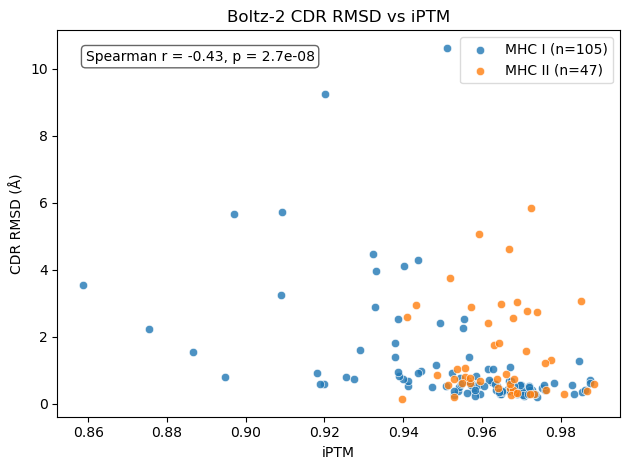

In [4]:
y = pdb_boltz.select("cdr_rmsd_boltz_4").to_series().to_numpy()
x = pdb_boltz.select("iptm").to_series().to_numpy()
mhc_class = pdb_boltz.select("mhc_class").to_series().to_numpy()

fig = plot_correlation(
    x,
    y,
    mhc_class,
    ylabel="CDR RMSD (Å)",
    xlabel="iPTM",
    method="spearman",
    title="Boltz-2 CDR RMSD vs iPTM",
)